# Simulazione d'esame Laboratorio di Programmazione 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [3]:
array = np.array([720,980,650,1200])
print(array)
tot = array.sum()
print(tot)
array = np.where(array==1200, array + array*0.12, array)
tot_1 = array.sum()
print(array)
array = np.where(array==650, array*0.9, array)
print(array)
array = np.where((array==720)|(array==980), array + array*0.05, array)
print(array)
print(array.sum())
print((tot-tot_1))

[ 720  980  650 1200]
3550
[ 720.  980.  650. 1344.]
[ 720.  980.  585. 1344.]
[ 756. 1029.  585. 1344.]
3714.0
-144.0


## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

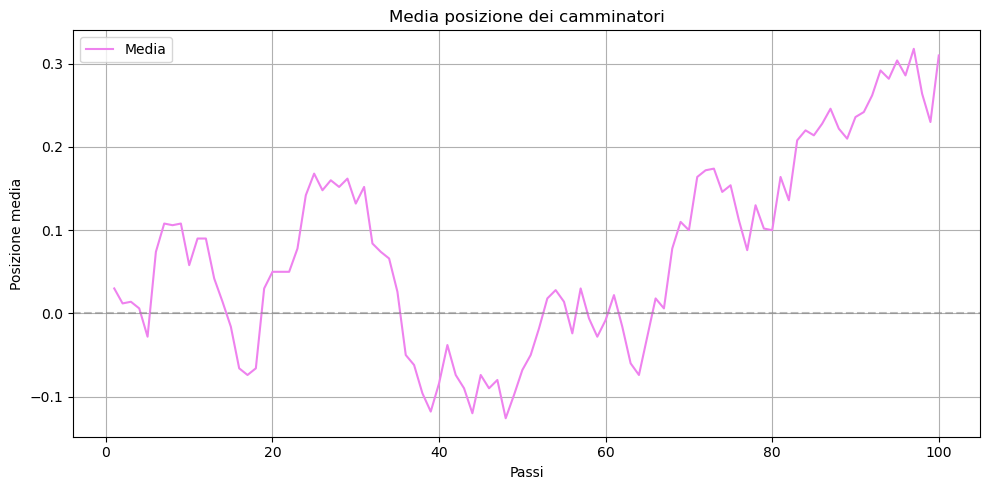

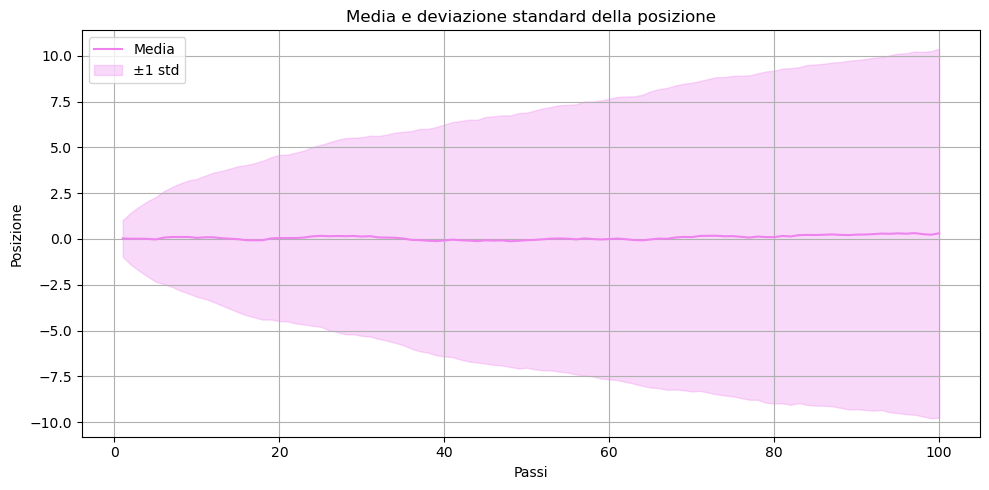

In [8]:
def random_walk(n, N):
    # matrice N x n: ogni riga è un camminatore, ogni colonna è un passo
    passi = np.random.choice([-1, 1], size=(N, n))
    # posizione cumulativa ad ogni passo
    posizioni = np.cumsum(passi, axis=1)  # somma cumulativa lungo i passi
    
    media = np.mean(posizioni, axis=0)  # media tra i camminatori ad ogni passo
    std = np.std(posizioni, axis=0)     # std tra i camminatori ad ogni passo
    return media, std

media, std = random_walk(n=100, N=1000)
passi_x = np.arange(1, 101)

# 2. Solo media
plt.figure(figsize=(10, 5))
plt.plot(passi_x, media, color='violet', label='Media')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Media posizione dei camminatori')
plt.xlabel('Passi')
plt.ylabel('Posizione media')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Media + deviazione standard
plt.figure(figsize=(10, 5))
plt.plot(passi_x, media, color='violet', label='Media')
plt.fill_between(passi_x, media - std, media + std, color='violet', alpha=0.3, label='±1 std')
plt.title('Media e deviazione standard della posizione')
plt.xlabel('Passi')
plt.ylabel('Posizione')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()


## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [11]:
np.random.seed(42)
a = np.random.normal(loc=0,scale=1, size=(5,9))

risultato = []
for riga in a:
    tmp = np.abs(riga - 0.1)
    idx = np.argmin(tmp)
    risultato.append(riga[idx])
risultato = np.array(risultato)

print(a)
print(risultato)

[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
   1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783
  -0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877 -0.2257763   0.0675282  -1.42474819
  -0.54438272  0.11092259 -1.15099358]
 [ 0.37569802 -0.60063869 -0.29169375 -0.60170661  1.85227818 -0.01349722
  -1.05771093  0.82254491 -1.22084365]
 [ 0.2088636  -1.95967012 -1.32818605  0.19686124  0.73846658  0.17136828
  -0.11564828 -0.3011037  -1.47852199]]
[-0.1382643   0.24196227  0.11092259 -0.01349722  0.17136828]


## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


                                      Name      Fare
258                       Ward, Miss. Anna  512.3292
679     Cardeza, Mr. Thomas Drake Martinez  512.3292
737                 Lesurer, Mr. Gustave J  512.3292
27          Fortune, Mr. Charles Alexander  263.0000
88              Fortune, Miss. Mabel Helen  263.0000
341         Fortune, Miss. Alice Elizabeth  263.0000
438                      Fortune, Mr. Mark  263.0000
311             Ryerson, Miss. Emily Borie  262.3750
742  Ryerson, Miss. Susan Parker "Suzette"  262.3750
118               Baxter, Mr. Quigg Edmond  247.5208

Media Age: 29.70
Media Fare: 32.20
Media SibSp: 0.52

Passeggero con Family_index massimo:
Name            Andersson, Miss. Erna Alexandra
SibSp                                         4
Parch                                         2
Fare                                      7.925
Family_index                           0.757098
Name: 68, dtype: object

Passeggeri con Fare > 100: 48


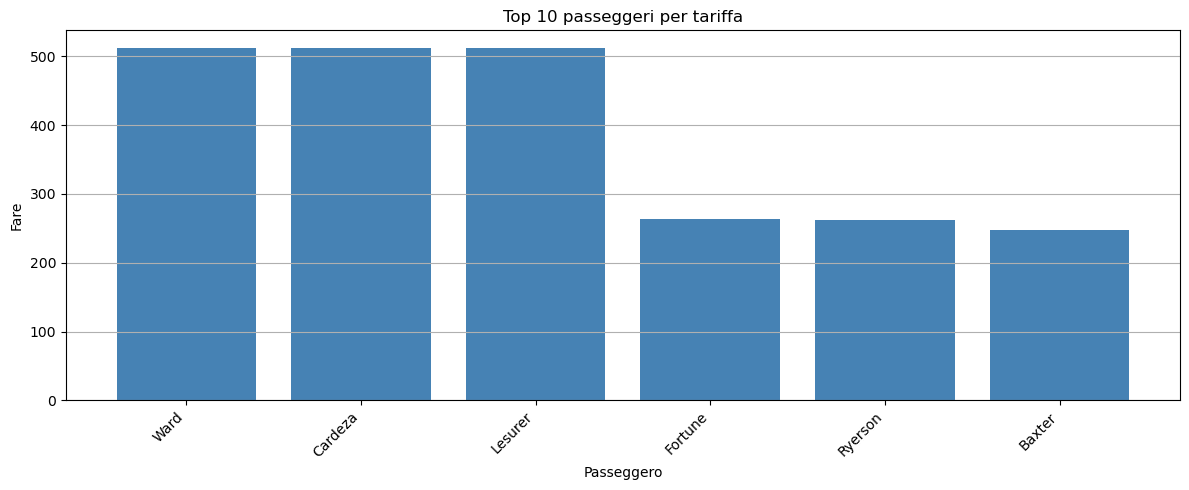

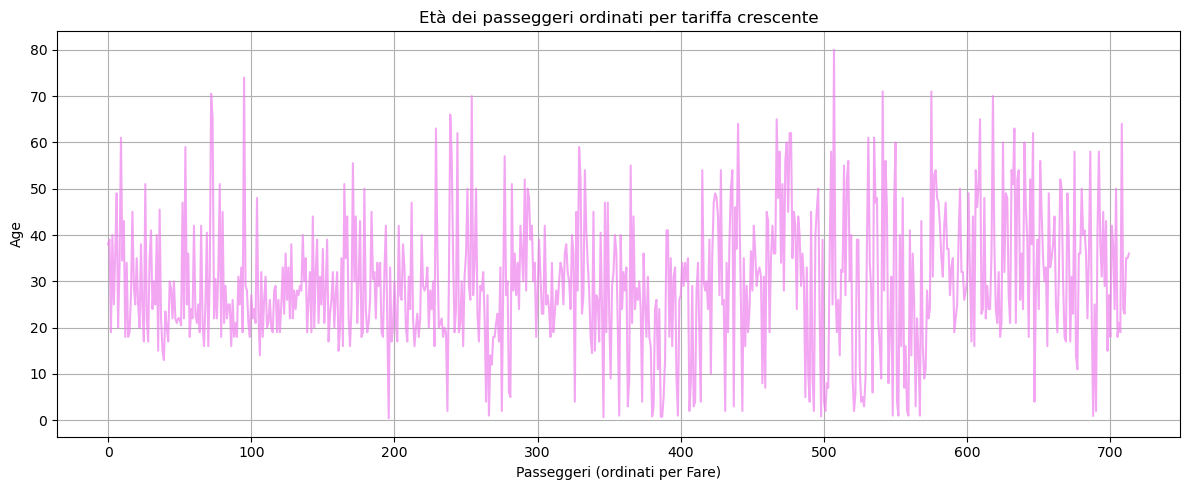

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 1. Primi 10 per tariffa
print(df.nlargest(10, 'Fare')[['Name', 'Fare']])

# 2. Medie
print(f"\nMedia Age: {df['Age'].mean():.2f}")
print(f"Media Fare: {df['Fare'].mean():.2f}")
print(f"Media SibSp: {df['SibSp'].mean():.2f}")

# 3. Family_index (gestisce divisione per zero)
df = df.dropna(subset=['Age', 'Fare'])
df['Family_index'] = (df['SibSp'] + df['Parch']) / df['Fare'].replace(0, float('nan'))

# 4. Passeggero con Family_index massimo
idx = df['Family_index'].idxmax()
print(f"\nPasseggero con Family_index massimo:\n{df.loc[idx, ['Name', 'SibSp', 'Parch', 'Fare', 'Family_index']]}")

# 5. Filtra Fare > 100
df_filtered = df[df['Fare'] > 100]
print(f"\nPasseggeri con Fare > 100: {len(df_filtered)}")

# 6. Grafico a barre top 10 per tariffa
top10 = df.nlargest(10, 'Fare')
plt.figure(figsize=(12, 5))
plt.bar(top10['Name'].str.split(',').str[0], top10['Fare'], color='steelblue')
plt.title('Top 10 passeggeri per tariffa')
plt.xlabel('Passeggero')
plt.ylabel('Fare')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 7. Grafico a linee Age ordinato per Fare
df_sorted = df.sort_values('Fare')
plt.figure(figsize=(12, 5))
plt.plot(range(len(df_sorted)), df_sorted['Age'], color='violet', alpha=0.7)
plt.title('Età dei passeggeri ordinati per tariffa crescente')
plt.xlabel('Passeggeri (ordinati per Fare)')
plt.ylabel('Age')
plt.grid(True)
plt.tight_layout()
plt.show()

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


Righe: 344, Colonne: 7

Valori mancanti:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Righe duplicate: 0

Massa media per specie:
species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


C:\Users\Viola\AppData\Local\Temp\ipykernel_7824\994236753.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='body_mass_g', palette='Set2')


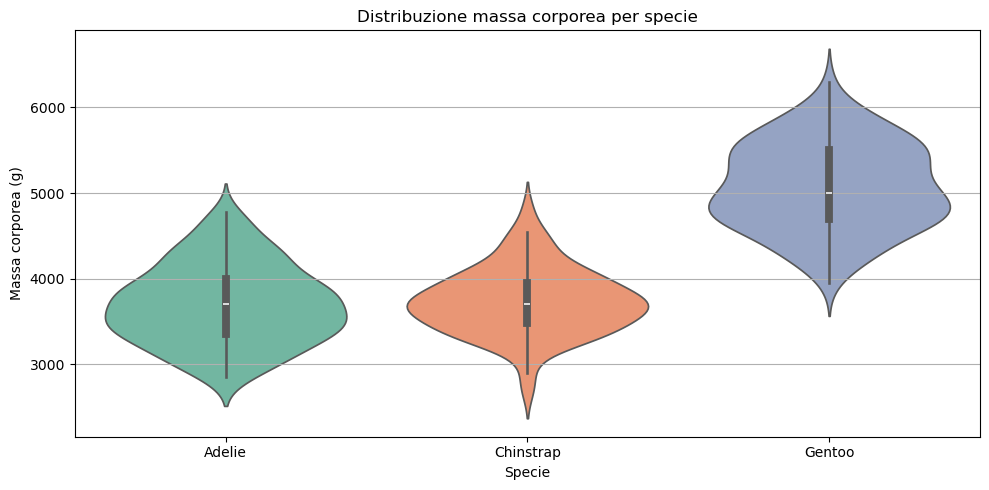

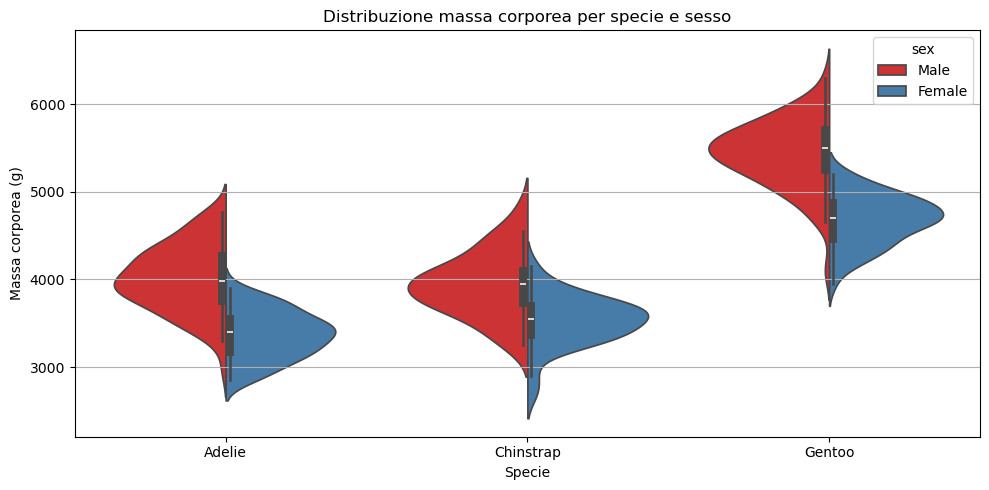

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")

# 1. Righe e colonne
print(f"Righe: {df.shape[0]}, Colonne: {df.shape[1]}")

# 2. Valori mancanti
print(f"\nValori mancanti:\n{df.isnull().sum()}")

# 3. Riempi sex con la moda
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

# 4. Rimuovi righe con body_mass_g mancante
df = df.dropna(subset=['body_mass_g'])

# 5. Righe duplicate
print(f"\nRighe duplicate: {df.duplicated().sum()}")

# 6. Massa media per specie + riempi mancanti
media_specie = df.groupby('species')['body_mass_g'].mean()
print(f"\nMassa media per specie:\n{media_specie}")
df['body_mass_g'] = df.groupby('species')['body_mass_g'].transform(lambda x: x.fillna(x.mean()))

# 7. Distribuzione massa per specie
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='species', y='body_mass_g', palette='Set2')
plt.title('Distribuzione massa corporea per specie')
plt.xlabel('Specie')
plt.ylabel('Massa corporea (g)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 8. Distribuzione massa per specie e sesso
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='species', y='body_mass_g', hue='sex', split=True, palette='Set1')
plt.title('Distribuzione massa corporea per specie e sesso')
plt.xlabel('Specie')
plt.ylabel('Massa corporea (g)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


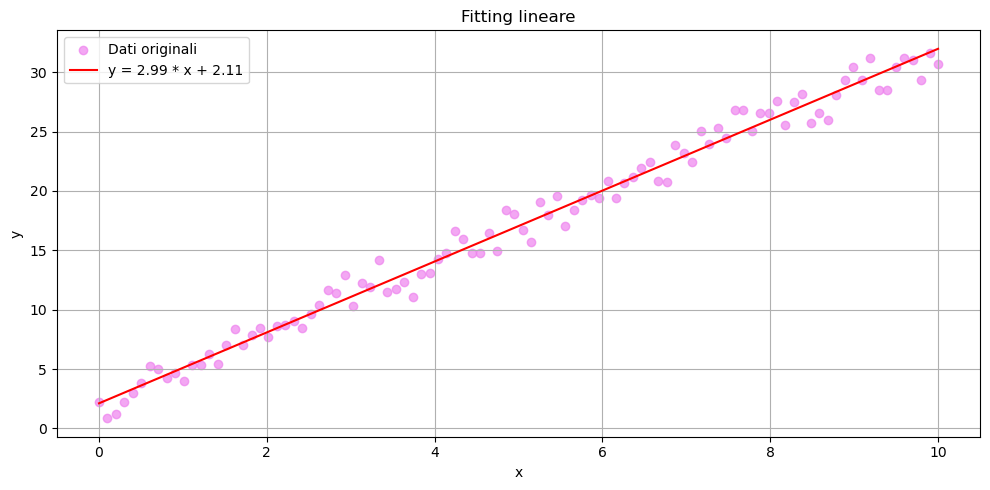

In [15]:
x = np.linspace(0, 10, 100)
y = 3 * x + 2 + np.random.normal(0, 1, 100)

def retta(x, a, b):
    return a*x + b

def fit_line(x, y):
    params, _ = curve_fit(retta, x, y)
    a, b = params
    stringa = f"y = {a:.2f} * x + {b:.2f}"

    return  (a, b), stringa

params, descrizione = fit_line(x, y)
a, b = params
y_fit = a * x + b

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='violet', alpha=0.7, label='Dati originali')
plt.plot(x, y_fit, color='red', label=descrizione)
plt.title('Fitting lineare')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()